# Baseline Analysis: FB-DDPG vs DIAYN
**EECS 598 — Reinforcement Learning Final Project**

This notebook loads `eval.csv` files from your training runs (from Google Drive), computes learning curves, and generates the three figures needed for the Analysis of Baseline section of your report.

---
### Structure
1. Mount Google Drive & set paths
2. Install / import dependencies
3. Load and inspect data
4. Figure 1 — All learning curves
5. Figure 2 — FB vs DIAYN on walker_walk (head-to-head)
6. Figure 3 — Final performance bar chart
7. Summary stats table

## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Set Base Directory

Update `BASE_DIR` to the folder in your Drive that contains all the run subfolders.

For example, if your runs live at `My Drive/RL_Project/runs/`, set:
```python
BASE_DIR = "/content/drive/MyDrive/RL_Project/runs"
```

In [ ]:
import os

# ── UPDATE THIS ──────────────────────────────────────────────────────────────
BASE_DIR = "/content/drive/MyDrive/Project 1 Evals/Project 1 Evals"   # <-- change this
# ─────────────────────────────────────────────────────────────────────────────

# Verify the path exists and show what's inside
assert os.path.exists(BASE_DIR), f"Path not found: {BASE_DIR}"
print("Contents of BASE_DIR:")
for item in sorted(os.listdir(BASE_DIR)):
    print(" ", item)

Contents of BASE_DIR:
  040441_diayn_walker_walk_online
  060149_fb_ddpg_quadruped_walk_online
  091356_diayn_cheetah_run_online
  092501_fb_ddpg_quadruped_walk_online
  101321_diayn_walker_walk_online
  121039_diayn_cheetah_run_online
  122214_fb_ddpg_quadruped_walk_online
  163347_diayn_cheetah_run_online
  175202_diayn_walker_walk_online
  185625_fb_ddpg_walker_walk_online
  204104_fb_ddpg_walker_walk_online
  215606_fb_ddpg_walker_walk_online


## 3. Run Configuration

Map each agent/task combo to its folder names. These match your training tracker.

In [ ]:
RUNS = {
    "FB / walker_walk": {
        "folders": [
            "215606_fb_ddpg_walker_walk_online",
            "185625_fb_ddpg_walker_walk_online",
            "204104_fb_ddpg_walker_walk_online",
        ],
        "color": "#2196F3",    # blue
        "linestyle": "-",
    },
    "FB / quadruped_walk": {
        "folders": [
            "060149_fb_ddpg_quadruped_walk_online",
            "092501_fb_ddpg_quadruped_walk_online",
            "122214_fb_ddpg_quadruped_walk_online",
        ],
        "color": "#4CAF50",    # green
        "linestyle": "-",
    },
    "DIAYN / walker_walk": {
        "folders": [
            "101321_diayn_walker_walk_online",
            "040441_diayn_walker_walk_online",
            "175202_diayn_walker_walk_online",
        ],
        "color": "#FF5722",    # orange-red
        "linestyle": "--",
    },
    "DIAYN / cheetah_run": {
        "folders": [
            "121039_diayn_cheetah_run_online",
            "163347_diayn_cheetah_run_online",
            "091356_diayn_cheetah_run_online",
        ],
        "color": "#9C27B0",    # purple
        "linestyle": "--",
    },
}

# Output folder for saved figures
FIG_DIR = "/content/figures"
os.makedirs(FIG_DIR, exist_ok=True)
print(f"Figures will be saved to: {FIG_DIR}")

Figures will be saved to: /content/figures


## 4. Helper Functions

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})


def load_eval_csvs(folders: list, base_dir: str) -> list:
    """Load eval.csv from each run folder. Warn and skip missing files."""
    dfs = []
    for folder in folders:
        path = Path(base_dir) / folder / "eval.csv"
        if not path.exists():
            print(f"  [WARNING] Not found: {path}")
            continue
        df = pd.read_csv(path)
        dfs.append(df)
        print(f"  Loaded {path.name} from {folder}  ({len(df)} rows)")
    return dfs


def smooth(values: np.ndarray, window: int = 5) -> np.ndarray:
    """Rolling-mean smoothing."""
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="same")


def align_and_aggregate(dfs: list, x_col: str = "frame", y_col: str = "episode_reward"):
    """
    Interpolate all seeds onto a shared x-grid, then return mean ± std.
    Returns (x_common, mean_array, std_array).
    """
    if not dfs:
        return None, None, None

    all_x = [df[x_col].values for df in dfs]
    x_min = max(arr.min() for arr in all_x)
    x_max = min(arr.max() for arr in all_x)
    n_points = max(len(arr) for arr in all_x)
    x_common = np.linspace(x_min, x_max, n_points)

    interpolated = []
    for df in dfs:
        y_interp = np.interp(x_common, df[x_col].values, df[y_col].values)
        interpolated.append(y_interp)

    stacked = np.array(interpolated)
    return x_common, stacked.mean(axis=0), stacked.std(axis=0)


def get_final_performance(dfs: list, y_col: str = "episode_reward", last_n_pct: float = 0.1):
    """Mean ± std of episode_reward over the last `last_n_pct` of training, across seeds."""
    finals = []
    for df in dfs:
        y = df[y_col].values
        n = max(1, int(len(y) * last_n_pct))
        finals.append(y[-n:].mean())
    return np.mean(finals), np.std(finals)


print("Helper functions loaded.")

Helper functions loaded.


## 5. Load & Inspect All Data

In [ ]:
all_data = {}

for label, cfg in RUNS.items():
    print(f"\n── {label}")
    dfs = load_eval_csvs(cfg["folders"], BASE_DIR)
    all_data[label] = dfs

print("\n── Column names (first available run):")
for label, dfs in all_data.items():
    if dfs:
        print(f"  {label}: {list(dfs[0].columns)}")
        break


── FB / walker_walk
  Loaded eval.csv from 215606_fb_ddpg_walker_walk_online  (241 rows)
  Loaded eval.csv from 185625_fb_ddpg_walker_walk_online  (241 rows)
  Loaded eval.csv from 204104_fb_ddpg_walker_walk_online  (241 rows)

── FB / quadruped_walk
  Loaded eval.csv from 060149_fb_ddpg_quadruped_walk_online  (241 rows)
  Loaded eval.csv from 092501_fb_ddpg_quadruped_walk_online  (241 rows)
  Loaded eval.csv from 122214_fb_ddpg_quadruped_walk_online  (241 rows)

── DIAYN / walker_walk
  Loaded eval.csv from 101321_diayn_walker_walk_online  (241 rows)
  Loaded eval.csv from 040441_diayn_walker_walk_online  (241 rows)
  Loaded eval.csv from 175202_diayn_walker_walk_online  (241 rows)

── DIAYN / cheetah_run
  Loaded eval.csv from 121039_diayn_cheetah_run_online  (241 rows)
  Loaded eval.csv from 163347_diayn_cheetah_run_online  (241 rows)
  Loaded eval.csv from 091356_diayn_cheetah_run_online  (241 rows)

── Column names (first available run):
  FB / walker_walk: ['episode', 'episode_l

/tmp/ipykernel_5919/3002344382.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


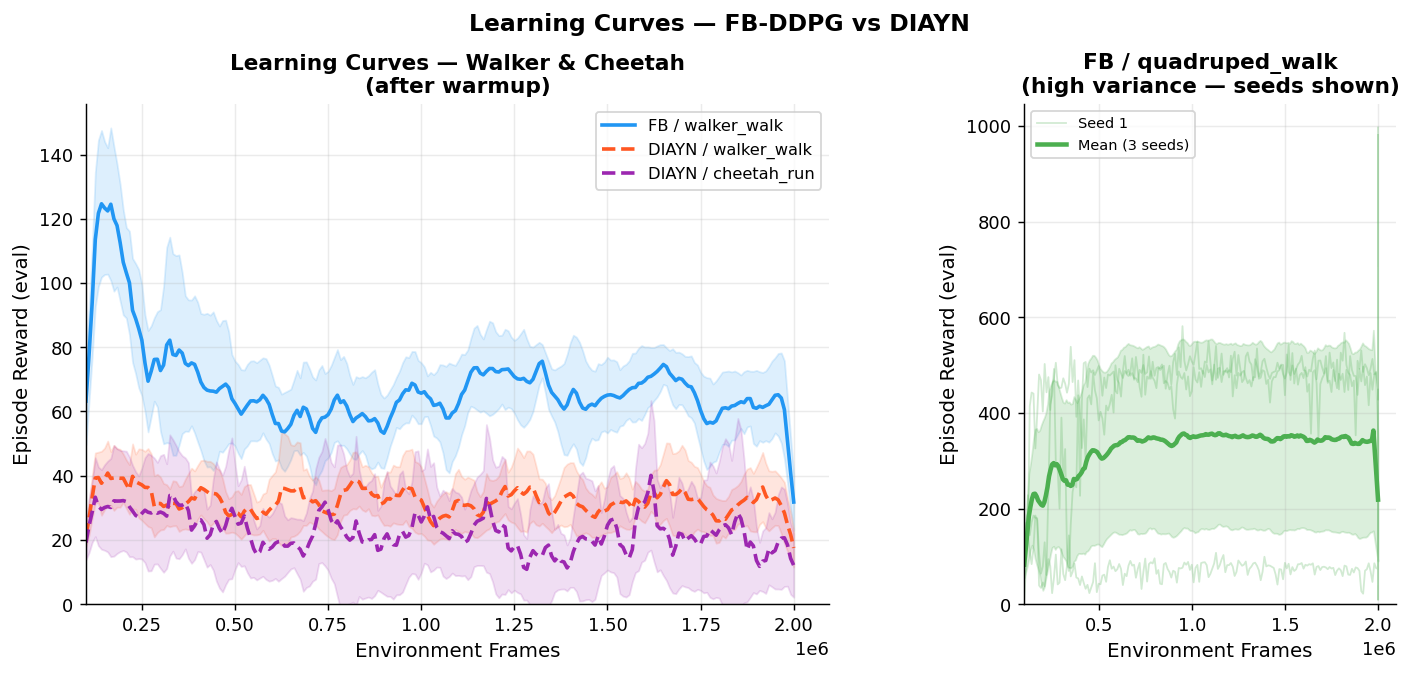

Saved: fig1_learning_curves_improved.png


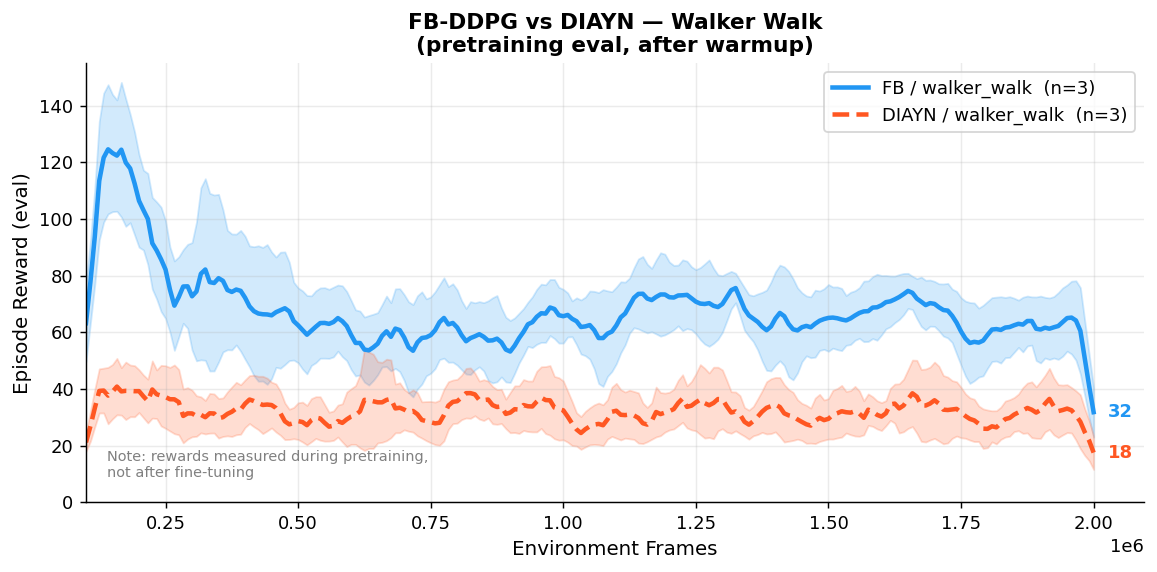

Saved: fig2_walker_head_to_head_improved.png


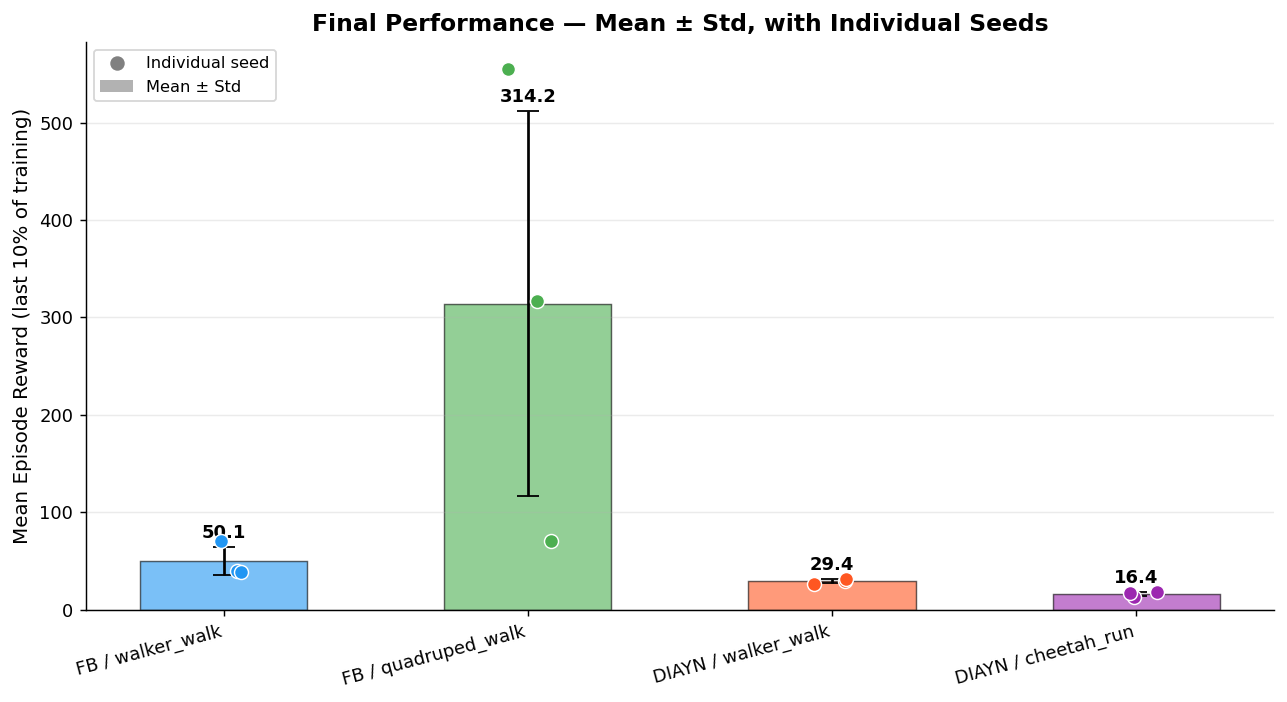

Saved: fig3_final_performance_improved.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Improved Baseline Analysis Figures
# Drop-in replacement for the plotting cells in your Colab notebook
# ─────────────────────────────────────────────────────────────────────────────

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ── Paste your RUNS dict and helper functions here (from previous notebook) ──
# (load_eval_csvs, smooth, align_and_aggregate, get_final_performance)
# ─────────────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
    "axes.labelsize": 11,
})

FIG_DIR = "/content/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 (improved): Two-panel layout
#   Left  — Walker-scale runs (FB walker + both DIAYN), x starts at 100k
#   Right — FB quadruped alone (different scale, shown separately)
# ─────────────────────────────────────────────────────────────────────────────

def plot_learning_curves_improved():
    fig = plt.figure(figsize=(13, 5))
    gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], wspace=0.35)
    ax_left  = fig.add_subplot(gs[0])
    ax_right = fig.add_subplot(gs[1])

    WALKER_SCALE_RUNS = ["FB / walker_walk", "DIAYN / walker_walk", "DIAYN / cheetah_run"]
    WARMUP_FRAMES = 100_000   # skip the noisy early phase

    # ── Left panel: walker-scale runs ────────────────────────────────────────
    for label in WALKER_SCALE_RUNS:
        cfg = RUNS[label]
        dfs = all_data[label]
        if not dfs:
            continue

        x, mean, std = align_and_aggregate(dfs)
        if x is None:
            continue

        # Crop early warmup
        mask = x >= WARMUP_FRAMES
        x, mean, std = x[mask], mean[mask], std[mask]

        mean_s = smooth(mean, window=7)
        std_s  = smooth(std,  window=7)

        ax_left.plot(x, mean_s, label=label, color=cfg["color"],
                     linestyle=cfg["linestyle"], linewidth=2)
        ax_left.fill_between(x, mean_s - std_s, mean_s + std_s,
                             alpha=0.15, color=cfg["color"])

    ax_left.set_xlabel("Environment Frames")
    ax_left.set_ylabel("Episode Reward (eval)")
    ax_left.set_title("Learning Curves — Walker & Cheetah\n(after warmup)", fontweight="bold")
    ax_left.legend(fontsize=9, loc="upper right")
    ax_left.grid(True, alpha=0.25)
    ax_left.set_xlim(left=WARMUP_FRAMES)
    ax_left.set_ylim(bottom=0)

    # ── Right panel: FB quadruped (its own scale) ─────────────────────────────
    cfg = RUNS["FB / quadruped_walk"]
    dfs = all_data["FB / quadruped_walk"]
    if dfs:
        x, mean, std = align_and_aggregate(dfs)
        mask = x >= WARMUP_FRAMES
        x, mean, std = x[mask], mean[mask], std[mask]
        mean_s = smooth(mean, window=7)
        std_s  = smooth(std,  window=7)

        # Plot individual seeds lightly to show the variance story
        for i, df in enumerate(dfs):
            xi = df["frame"].values
            yi = df["episode_reward"].values
            mask_i = xi >= WARMUP_FRAMES
            ax_right.plot(xi[mask_i], yi[mask_i],
                          color=cfg["color"], alpha=0.25, linewidth=1,
                          label=f"Seed {i+1}" if i == 0 else None)

        ax_right.plot(x, mean_s, color=cfg["color"], linewidth=2.5,
                      label="Mean (3 seeds)")
        ax_right.fill_between(x, mean_s - std_s, mean_s + std_s,
                              alpha=0.2, color=cfg["color"])

    ax_right.set_xlabel("Environment Frames")
    ax_right.set_ylabel("Episode Reward (eval)")
    ax_right.set_title("FB / quadruped_walk\n(high variance — seeds shown)", fontweight="bold")
    ax_right.legend(fontsize=8)
    ax_right.grid(True, alpha=0.25)
    ax_right.set_xlim(left=WARMUP_FRAMES)
    ax_right.set_ylim(bottom=0)

    fig.suptitle("Learning Curves — FB-DDPG vs DIAYN", fontsize=13,
                 fontweight="bold", y=1.02)
    fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/fig1_learning_curves_improved.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig1_learning_curves_improved.png")


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2 (improved): Walker head-to-head, x starts at 100k, annotated
# ─────────────────────────────────────────────────────────────────────────────

def plot_walker_head_to_head_improved():
    fig, ax = plt.subplots(figsize=(9, 4.5))

    WARMUP_FRAMES = 100_000

    for label in ["FB / walker_walk", "DIAYN / walker_walk"]:
        cfg = RUNS[label]
        dfs = all_data[label]
        if not dfs:
            continue

        x, mean, std = align_and_aggregate(dfs)
        mask = x >= WARMUP_FRAMES
        x, mean, std = x[mask], mean[mask], std[mask]
        mean_s = smooth(mean, window=7)
        std_s  = smooth(std,  window=7)

        ax.plot(x, mean_s, label=f"{label}  (n={len(dfs)})",
                color=cfg["color"], linestyle=cfg["linestyle"], linewidth=2.5)
        ax.fill_between(x, mean_s - std_s, mean_s + std_s,
                        alpha=0.2, color=cfg["color"])

        # Annotate final value
        final_val = mean_s[-1]
        ax.annotate(f"{final_val:.0f}",
                    xy=(x[-1], final_val),
                    xytext=(8, 0), textcoords="offset points",
                    color=cfg["color"], fontsize=10, fontweight="bold",
                    va="center")

    ax.set_xlabel("Environment Frames")
    ax.set_ylabel("Episode Reward (eval)")
    ax.set_title("FB-DDPG vs DIAYN — Walker Walk\n(pretraining eval, after warmup)",
                 fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(left=WARMUP_FRAMES)
    ax.set_ylim(bottom=0)

    # Add note about metric
    ax.text(0.02, 0.05,
            "Note: rewards measured during pretraining,\nnot after fine-tuning",
            transform=ax.transAxes, fontsize=8, color="gray",
            verticalalignment="bottom")

    fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/fig2_walker_head_to_head_improved.png", dpi=150)
    plt.show()
    print("Saved: fig2_walker_head_to_head_improved.png")


# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3 (improved): Bar chart + individual seed dots (strip plot)
# ─────────────────────────────────────────────────────────────────────────────

def plot_final_performance_improved():
    fig, ax = plt.subplots(figsize=(10, 5.5))

    labels, means, stds, colors = [], [], [], []
    seed_values = {}   # label -> list of per-seed final rewards

    for label, cfg in RUNS.items():
        dfs = all_data[label]
        labels.append(label)
        colors.append(cfg["color"])
        if dfs:
            m, s = get_final_performance(dfs)
            # Per-seed values for strip plot
            per_seed = []
            for df in dfs:
                y = df["episode_reward"].values
                n = max(1, int(len(y) * 0.1))
                per_seed.append(y[-n:].mean())
            means.append(m)
            stds.append(s)
            seed_values[label] = per_seed
        else:
            means.append(0)
            stds.append(0)
            seed_values[label] = []

    x = np.arange(len(labels))

    # Bars (lighter, so dots are visible on top)
    bars = ax.bar(x, means, yerr=stds, capsize=6, color=colors,
                  width=0.55, edgecolor="black", linewidth=0.8,
                  alpha=0.6, error_kw={"linewidth": 1.5})

    # Individual seed dots (strip plot)
    rng = np.random.default_rng(42)
    for i, (label, seeds) in enumerate(seed_values.items()):
        jitter = rng.uniform(-0.08, 0.08, len(seeds))
        ax.scatter(x[i] + jitter, seeds,
                   color=colors[i], s=60, zorder=5,
                   edgecolors="white", linewidths=0.8)

    # Mean value labels
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + s + max(means) * 0.015,
                f"{m:.1f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=10)
    ax.set_ylabel("Mean Episode Reward (last 10% of training)")
    ax.set_title("Final Performance — Mean ± Std, with Individual Seeds",
                 fontsize=13, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.25)
    ax.set_ylim(bottom=0)

    # Legend for dots vs bars
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='gray', label='Individual seed',
               markerfacecolor='gray', markersize=7, linestyle='None'),
        plt.Rectangle((0, 0), 1, 1, fc='gray', alpha=0.6, label='Mean ± Std'),
    ]
    ax.legend(handles=legend_elements, fontsize=9, loc="upper left")

    fig.tight_layout()
    fig.savefig(f"{FIG_DIR}/fig3_final_performance_improved.png", dpi=150)
    plt.show()
    print("Saved: fig3_final_performance_improved.png")


# ─────────────────────────────────────────────────────────────────────────────
# RUN ALL
# ─────────────────────────────────────────────────────────────────────────────
plot_learning_curves_improved()
plot_walker_head_to_head_improved()
plot_final_performance_improved()

## 6. Figure 1 — All Learning Curves

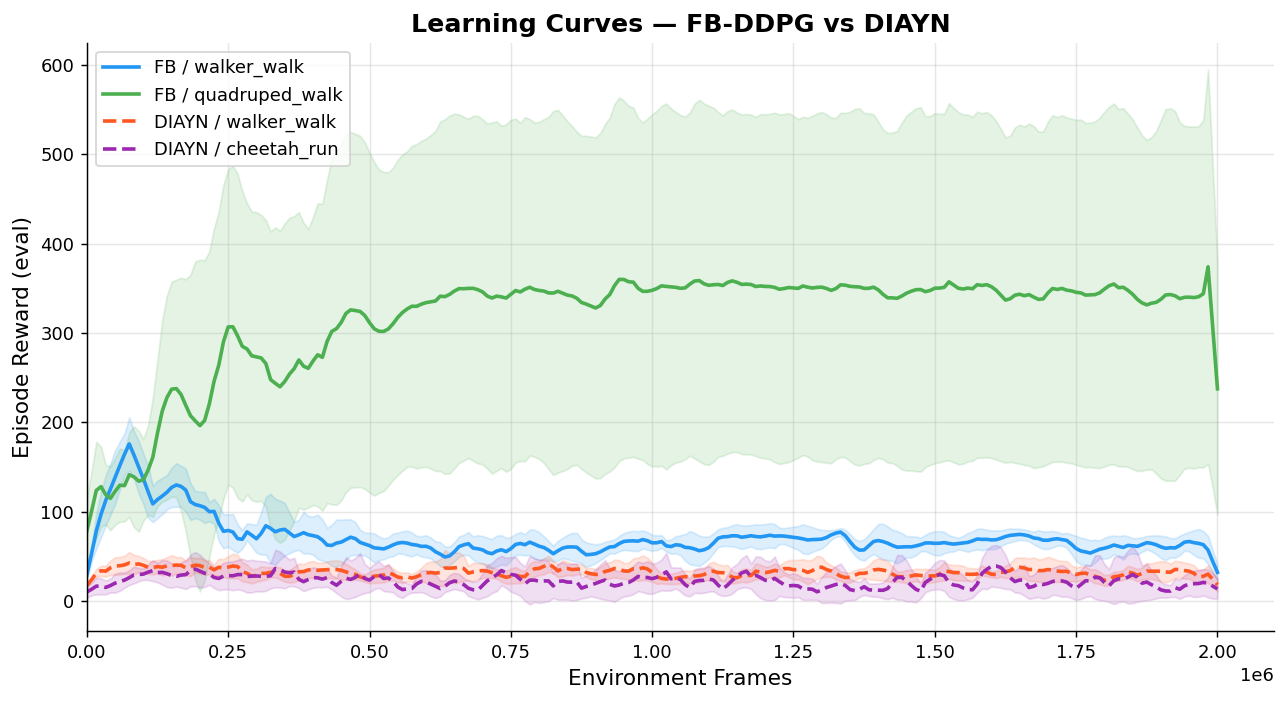

Saved fig1_all_learning_curves.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5.5))

for label, cfg in RUNS.items():
    dfs = all_data[label]
    if not dfs:
        continue

    x, mean, std = align_and_aggregate(dfs)
    if x is None:
        continue

    mean_s = smooth(mean)
    std_s  = smooth(std)

    ax.plot(x, mean_s, label=label, color=cfg["color"],
            linestyle=cfg["linestyle"], linewidth=2)
    ax.fill_between(x, mean_s - std_s, mean_s + std_s,
                    alpha=0.15, color=cfg["color"])

ax.set_xlabel("Environment Frames", fontsize=12)
ax.set_ylabel("Episode Reward (eval)", fontsize=12)
ax.set_title("Learning Curves — FB-DDPG vs DIAYN", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig1_all_learning_curves.png", dpi=150)
plt.show()
print("Saved fig1_all_learning_curves.png")

## 7. Figure 2 — FB vs DIAYN on walker_walk (Head-to-Head)

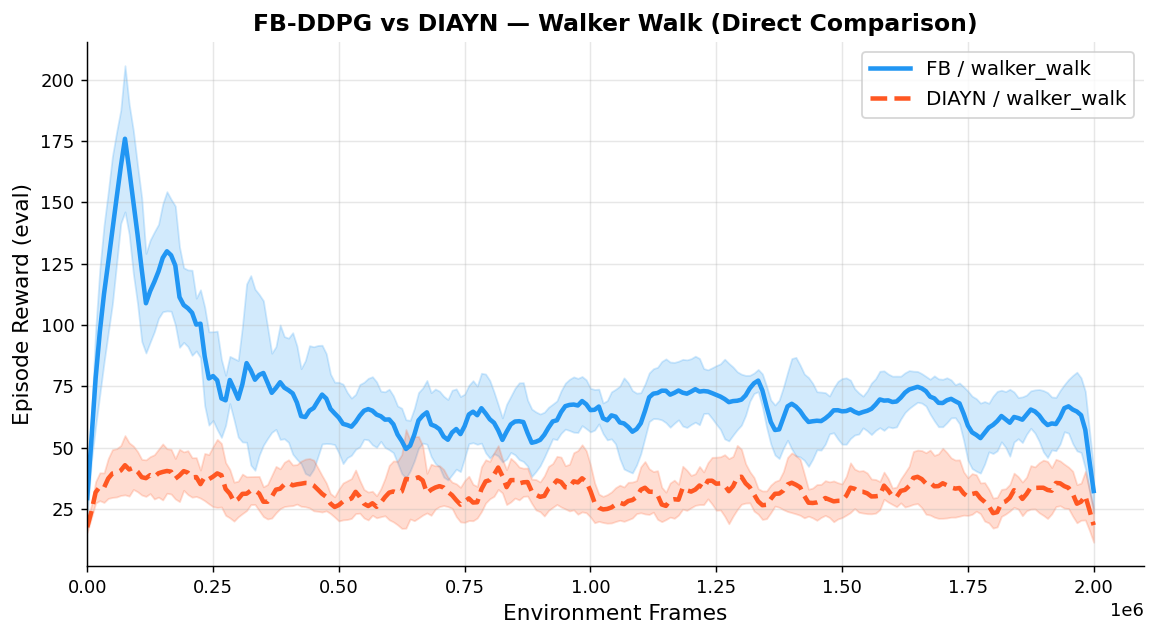

Saved fig2_walker_head_to_head.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for label in ["FB / walker_walk", "DIAYN / walker_walk"]:
    cfg = RUNS[label]
    dfs = all_data[label]
    if not dfs:
        print(f"No data for {label}")
        continue

    x, mean, std = align_and_aggregate(dfs)
    if x is None:
        continue

    mean_s = smooth(mean)
    std_s  = smooth(std)

    ax.plot(x, mean_s, label=label, color=cfg["color"],
            linestyle=cfg["linestyle"], linewidth=2.5)
    ax.fill_between(x, mean_s - std_s, mean_s + std_s,
                    alpha=0.2, color=cfg["color"])

ax.set_xlabel("Environment Frames", fontsize=12)
ax.set_ylabel("Episode Reward (eval)", fontsize=12)
ax.set_title("FB-DDPG vs DIAYN — Walker Walk (Direct Comparison)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig2_walker_head_to_head.png", dpi=150)
plt.show()
print("Saved fig2_walker_head_to_head.png")

## 8. Figure 3 — Final Performance Bar Chart

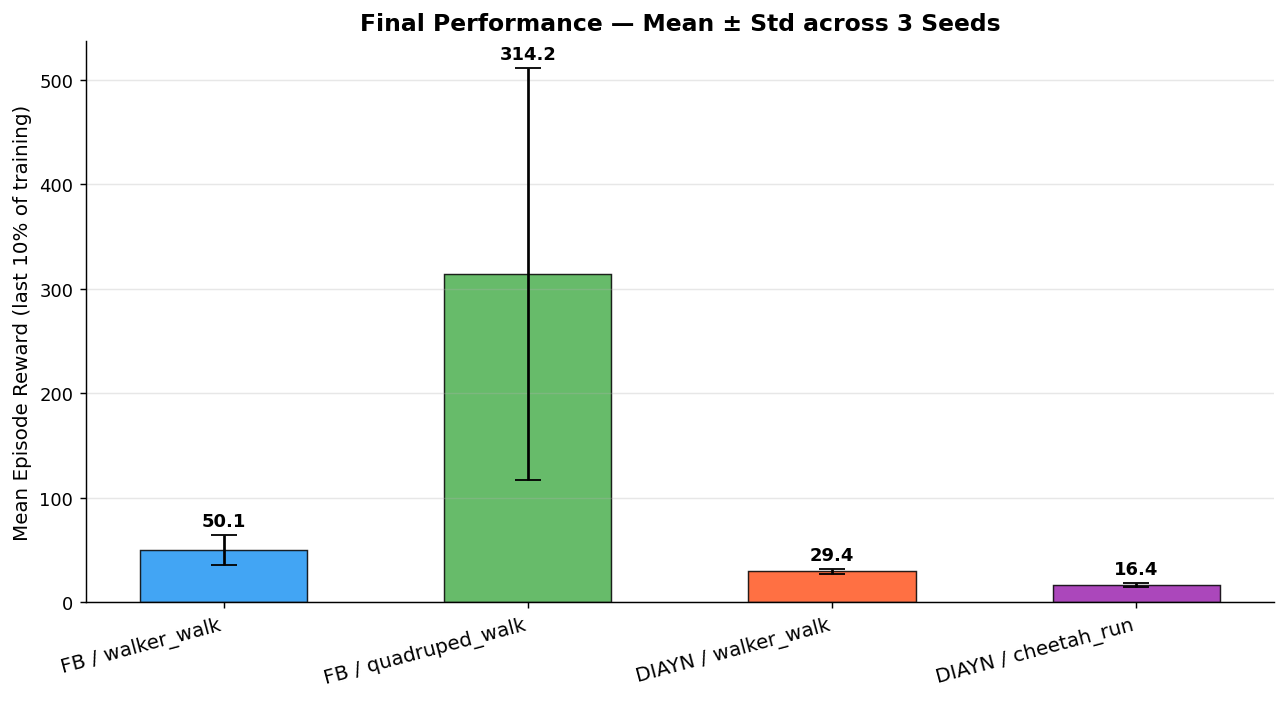

Saved fig3_final_performance_bars.png


In [ ]:
labels, means, stds, colors = [], [], [], []

for label, cfg in RUNS.items():
    dfs = all_data[label]
    labels.append(label)
    colors.append(cfg["color"])
    if dfs:
        m, s = get_final_performance(dfs)
        means.append(m)
        stds.append(s)
    else:
        means.append(0)
        stds.append(0)

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.bar(x, means, yerr=stds, capsize=7, color=colors,
              width=0.55, edgecolor="black", linewidth=0.8, alpha=0.85)

# Value labels on top of bars
for bar, m, s in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + s + max(means) * 0.015,
        f"{m:.1f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=11)
ax.set_ylabel("Mean Episode Reward (last 10% of training)", fontsize=11)
ax.set_title("Final Performance — Mean ± Std across 3 Seeds",
             fontsize=13, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)
ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/fig3_final_performance_bars.png", dpi=150)
plt.show()
print("Saved fig3_final_performance_bars.png")

## 9. Summary Stats Table

In [ ]:
rows = []
for label, cfg in RUNS.items():
    dfs = all_data[label]
    n_seeds = len(dfs)
    if dfs:
        m, s = get_final_performance(dfs)
        # Max reward ever seen (across all seeds)
        max_reward = max(df["episode_reward"].max() for df in dfs)
    else:
        m, s, max_reward = 0, 0, 0
    rows.append({
        "Run": label,
        "Seeds loaded": n_seeds,
        "Final mean reward": round(m, 2),
        "Final std": round(s, 2),
        "Peak reward (any seed)": round(max_reward, 2),
    })

summary_df = pd.DataFrame(rows).set_index("Run")
display(summary_df)

,Seeds loaded,Final mean reward,Final std,Peak reward (any seed)
Run,,,,
FB / walker_walk,3,50.09,14.62,449.33
FB / quadruped_walk,3,314.20,197.71,997.48
DIAYN / walker_walk,3,29.41,2.19,492.12
DIAYN / cheetah_run,3,16.36,2.26,275.45


## 10. Download Figures from Colab

Run this cell to download all three figures to your local machine.

In [ ]:
from google.colab import files

for fname in ["fig1_all_learning_curves.png",
              "fig2_walker_head_to_head.png",
              "fig3_final_performance_bars.png"]:
    fpath = f"{FIG_DIR}/{fname}"
    if os.path.exists(fpath):
        files.download(fpath)
        print(f"Downloading {fname}")
    else:
        print(f"[SKIP] {fname} not found — run the figure cells above first")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
from pathlib import Path

BASE_DIR = "/content/drive/MyDrive/Project 1 Evals/Project 1 Evals"   # your path

for folder in os.listdir(BASE_DIR):
    models_path = Path(BASE_DIR) / folder / "models"
    if models_path.exists():
        snaps = list(models_path.glob("snapshot_*.pt"))
        print(f"{folder}: {sorted([s.name for s in snaps])}")

234805_diayn_walker_walk_online: ['snapshot_100000.pt', 'snapshot_1000000.pt', 'snapshot_200000.pt', 'snapshot_500000.pt', 'snapshot_800000.pt']


In [ ]:
!python -m url_benchmark.finetune pretrained_agent=diayn task=walker_walk snapshot_ts=1000000 obs_type=states reward_free=false seed=1

/usr/bin/python3: Error while finding module specification for 'url_benchmark.finetune' (ModuleNotFoundError: No module named 'url_benchmark')


In [ ]:
import os

# ── UPDATE THIS ───────────────────────────────────────────────────────────────
ZIPS_DIR = "/content/drive/MyDrive/Colab Notebooks/controllable_agent/baseline_analysis"  # folder with your .zip files
# ─────────────────────────────────────────────────────────────────────────────

EXTRACT_DIR  = "/content/runs"          # where zips get extracted (local, fast)
REPO_DIR     = "/content/controllable_agent"
FINETUNE_OUT = "/content/finetune_runs" # fine-tuning outputs go here

os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(FINETUNE_OUT, exist_ok=True)

# Each entry: (agent_name, task, pretrained_agent_flag)
# pretrained_agent_flag is the value passed to --pretrained_agent in finetune.py
RUNS = {
    "FB / walker_walk": {
        "agent":      "fb_ddpg",
        "task":       "walker_walk",
        "reward_free": True,
        "zip_names": [
            "215606_fb_ddpg_walker_walk_online.zip",
            "185625_fb_ddpg_walker_walk_online.zip",
            "204104_fb_ddpg_walker_walk_online.zip",
        ],
        "color": "#2196F3",
    },
    "FB / quadruped_walk": {
        "agent":      "fb_ddpg",
        "task":       "quadruped_walk",
        "reward_free": True,
        "zip_names": [
            "060149_fb_ddpg_quadruped_walk_online.zip",
            "092501_fb_ddpg_quadruped_walk_online.zip",
            "122214_fb_ddpg_quadruped_walk_online.zip",
        ],
        "color": "#4CAF50",
    },
    "DIAYN / walker_walk": {
        "agent":      "diayn",
        "task":       "walker_walk",
        "reward_free": False,   # switched OFF for fine-tuning
        "zip_names": [
            "101321_diayn_walker_walk_online.zip",
            "040441_diayn_walker_walk_online.zip",
            "175202_diayn_walker_walk_online.zip",
        ],
        "color": "#FF5722",
    },
    "DIAYN / cheetah_run": {
        "agent":      "diayn",
        "task":       "cheetah_run",
        "reward_free": False,
        "zip_names": [
            "121039_diayn_cheetah_run_online.zip",
            "163347_diayn_cheetah_run_online.zip",
            "091356_diayn_cheetah_run_online.zip",
        ],
        "color": "#9C27B0",
    },
}

SNAPSHOT_TS = 2000000   # use 2M frame checkpoint

print("Config set. ZIPS_DIR:", ZIPS_DIR)
print("Zip files found:")
for f in sorted(os.listdir(ZIPS_DIR)):
    if f.endswith(".zip"):
        print(" ", f)

Config set. ZIPS_DIR: /content/drive/MyDrive/Colab Notebooks/controllable_agent/baseline_analysis
Zip files found:
  060149_fb_ddpg_quadruped_walk_online-20260325T191312Z-1-001.zip
  091356_diayn_cheetah_run_online.zip
  101321_diayn_walker_walk_online.zip
  121039_diayn_cheetah_run_online.zip
  122214_fb_ddpg_quadruped_walk_online.zip
  163347_diayn_cheetah_run_online.zip
  185625_fb_ddpg_walker_walk_online.zip
  204104_fb_ddpg_walker_walk_online.zip
  215606_fb_ddpg_walker_walk_online.zip
